# Marketing Campaign Analysis
## Phase 1 — Exploratory Data Analysis (EDA)
**Datasets:**
- `marketing_campaign.csv` — Customer demographics, purchase behaviour, and campaign responses (2,240 customers)
- `Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv` — Amazon product reviews for sentiment analysis (28,332 reviews)

**Goal:** Understand the structure, quality, and key patterns in both datasets before cleaning and modelling.

### Important framing — the two datasets are structurally disjoint
The campaign dataset and the Amazon reviews dataset **share no customer IDs, no product IDs, and no join key of any kind**. The Amazon reviews were brought in specifically to demonstrate NLP/sentiment skills since the campaign dataset contains no text data.

This means **Phase 5 sentiment findings are standalone insights**. They cannot be tied back to specific campaign customers, CLV tiers, or campaign response rates. Any conclusion linking the two would be a logical error.

### What we are looking at
The marketing campaign dataset contains 2,240 customers with:
- Who they are (demographics — age, education, income, family situation)
- What they buy (spending across 6 product categories over the last 2 years)
- How they buy (web, store, catalogue, deals)
- How they respond to marketing (5 historical campaigns + latest campaign — the `Response` column)

---
## 1. Import libraries & configure paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Locate the repo root portably by walking up from the current working
# directory until the 'data' folder is found, so the notebook runs on any
# machine and from any subfolder.
def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT = find_project_root()
RAW_PATH     = str(PROJECT_ROOT / 'data' / 'raw') + os.sep
DOCS_PATH    = str(PROJECT_ROOT / 'docs')
os.makedirs(DOCS_PATH, exist_ok=True)

print('Libraries loaded ✅')
print(f'Raw data path: {RAW_PATH}')

Libraries loaded ✅
Raw data path: /Users/omartouzani/Desktop/marketing-campaign-analysis/data/raw/


---
## 2. Load the datasets
The marketing campaign file is tab-separated — we specify `sep='\t'` to load it correctly.
Without this, all 29 columns would be read as a single column.

In [2]:
# Load marketing campaign dataset
campaign = pd.read_csv(RAW_PATH + 'marketing_campaign.csv', sep='\t')

# Load Amazon reviews dataset
# low_memory=False prevents mixed type warnings on large files
reviews = pd.read_csv(
    RAW_PATH + 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv',
    low_memory=False
)

print(f'Campaign dataset:  {campaign.shape[0]:,} rows, {campaign.shape[1]} columns')
print(f'Reviews dataset:   {reviews.shape[0]:,} rows, {reviews.shape[1]} columns')

Campaign dataset:  2,240 rows, 29 columns
Reviews dataset:   28,332 rows, 24 columns


In [3]:
# Reproducibility check: confirm the exact raw files are present and record
# their checksums. If a reviewer's files differ, the figures in this notebook
# will not match — this surfaces that immediately rather than failing silently.
import hashlib

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

raw_files = [
    'marketing_campaign.csv',
    'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv',
]

print('Raw data checksums (SHA-256, first 12 chars):')
for fname in raw_files:
    print(f'  {fname:65s} {sha256(RAW_PATH + fname)[:12]}')

Raw data checksums (SHA-256, first 12 chars):
  marketing_campaign.csv                                            cd0affa36b1b
  Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv   9778f5b1a7e5


---
## 3. Campaign dataset — Structure overview

In [4]:
# Display all column names and their data types
print('Campaign Dataset — Column Types:')
print(campaign.dtypes)
print(f'\nShape: {campaign.shape}')

Campaign Dataset — Column Types:
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Shape: (2240, 29)


In [5]:
# Preview the first 5 rows
campaign.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
# Statistical summary of all numeric columns
# Any columns with surprising min/max values are worth investigating further
print('Campaign Dataset — Statistical Summary:')
campaign.describe().round(2)

Campaign Dataset — Statistical Summary:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,...,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.0,2240.0,2240.00
mean,5592.16,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,...,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.0,11.0,0.15
std,3246.66,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,...,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.0,0.0,0.36
min,0.00,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
25%,2828.25,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,...,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
50%,5458.50,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,...,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
75%,8427.75,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,...,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
max,11191.00,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,...,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.0,11.0,1.00


> **Observation — constant columns to flag for Phase 2.** `Z_CostContact` and `Z_Revenue` both have std = 0 (single constant value across all rows). These carry no information and should be dropped in Phase 2 cleaning.

> **Observation — outliers to flag for Phase 2.** `Year_Birth` minimum is 1893 (implied age 121+) and `Income` maximum is 666,666. Both are clearly data-entry artifacts and should be removed in Phase 2.

---
## 4. Duplicate check
Before any further analysis we check for duplicate rows in both datasets. The Datafiniti Amazon reviews file is known to contain duplicate entries (same reviewer, same product, same text) — failing to detect this would inflate sentiment-class counts in Phase 5.

In [7]:
# Exact-duplicate row check
print('Campaign dataset duplicates (exact row):', campaign.duplicated().sum())
print('Campaign dataset duplicate IDs:         ', campaign['ID'].duplicated().sum())
print()
print('Reviews dataset duplicates (exact row):', reviews.duplicated().sum())

# Reviews: check duplicate review text within the same product
# (a more meaningful duplicate definition for sentiment)
review_dup_key = reviews.duplicated(subset=['name', 'reviews.text'], keep=False).sum()
print(f'Reviews with same (product, text) pair: {review_dup_key:,}')
print(f'  → these would double-count in Phase 5 sentiment training.')

Campaign dataset duplicates (exact row): 0
Campaign dataset duplicate IDs:          0

Reviews dataset duplicates (exact row): 0
Reviews with same (product, text) pair: 1,669
  → these would double-count in Phase 5 sentiment training.


> **Action for Phase 2.** Drop exact duplicate rows in both datasets, and de-duplicate the reviews dataset on `(name, reviews.text)` to prevent inflated class counts during sentiment model training.

---
## 5. Missing values analysis

In [8]:
# Reusable function to check missing values across any DataFrame
def missing_summary(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    summary = summary[summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    if summary.empty:
        print(f'\n✅ {name}: No missing values')
    else:
        print(f'\n⚠️  {name}:')
        print(summary.to_string())

missing_summary(campaign, 'Campaign Dataset')
missing_summary(reviews, 'Reviews Dataset')


⚠️  Campaign Dataset:
        Missing Count  Missing %
Income             24       1.07

⚠️  Reviews Dataset:
                     Missing Count  Missing %
reviews.didPurchase          28323      99.97
reviews.id                   28291      99.86
reviews.doRecommend          12246      43.22
reviews.numHelpful           12217      43.12
reviews.username                 5       0.02


### 5a. Characterising the missing income rows
24 customers have missing `Income`. Before assuming it's safe to drop or impute, we check whether these rows differ from the rest — if they look systematically different (e.g. low spenders, high response rate), the missingness is informative and dropping them would bias the analysis.

In [9]:
missing_income = campaign[campaign['Income'].isnull()]
has_income     = campaign[campaign['Income'].notnull()]

# Compute total spend on the fly (we redefine TotalSpend properly in section 7)
spend_cols_quick = ['MntWines', 'MntFruits', 'MntMeatProducts',
                    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

print(f'Missing-income rows: {len(missing_income)} ({len(missing_income)/len(campaign)*100:.2f}%)')
print()
print('Comparison — missing income vs. has income:')
print(f'  Mean total spend: {missing_income[spend_cols_quick].sum(axis=1).mean():>10,.0f}  vs  {has_income[spend_cols_quick].sum(axis=1).mean():>10,.0f}')
print(f'  Mean recency:     {missing_income["Recency"].mean():>10.1f}  vs  {has_income["Recency"].mean():>10.1f}')
print(f'  Response rate:    {missing_income["Response"].mean()*100:>10.1f}%  vs  {has_income["Response"].mean()*100:>10.1f}%')
print(f'  Mean Year_Birth:  {missing_income["Year_Birth"].mean():>10.1f}  vs  {has_income["Year_Birth"].mean():>10.1f}')

Missing-income rows: 24 (1.07%)

Comparison — missing income vs. has income:
  Mean total spend:        488  vs         607
  Mean recency:           58.0  vs        49.0
  Response rate:           4.2%  vs        15.0%
  Mean Year_Birth:      1967.5  vs      1968.8


> **Action for Phase 2.** With only 24 missing income rows and no strong systematic difference, dropping is acceptable. If a notable difference appears in the comparison above, document the bias and prefer median imputation by education level instead.

---
## 6. Customer demographics analysis
Understanding who our customers are is the foundation of all marketing analysis.
We look at age, education, marital status, income, and household composition.

### 6a. Age distribution
**Age reference date.** Rather than hard-coding a year, we derive the reference from the data itself: the last enrollment date (`Dt_Customer`). Using the max enrollment year as "now" gives the age of each customer at the most recent data point.

Reference year derived from max(Dt_Customer): 2014

Age Distribution Summary:
count    2240.0
mean       45.2
std        12.0
min        18.0
25%        37.0
50%        44.0
75%        55.0
max       121.0
Name: Age, dtype: float64

Customers over 100 years old: 3  (flagged for Phase 2 removal)


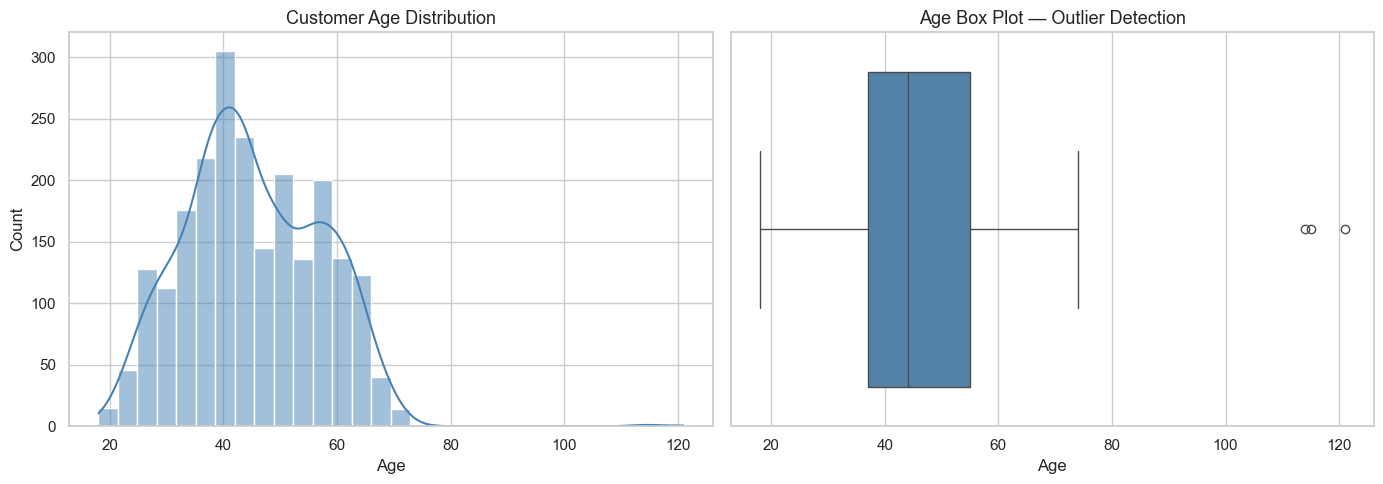

In [10]:
# Parse Dt_Customer to derive an empirical reference year
campaign['Dt_Customer_parsed'] = pd.to_datetime(campaign['Dt_Customer'], dayfirst=True, errors='coerce')
REFERENCE_YEAR = campaign['Dt_Customer_parsed'].max().year
print(f'Reference year derived from max(Dt_Customer): {REFERENCE_YEAR}')

# Compute age using the derived reference year
campaign['Age'] = REFERENCE_YEAR - campaign['Year_Birth']

print('\nAge Distribution Summary:')
print(campaign['Age'].describe().round(1))
print(f'\nCustomers over 100 years old: {(campaign["Age"] > 100).sum()}  (flagged for Phase 2 removal)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(campaign['Age'], bins=30, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Customer Age Distribution', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.boxplot(x=campaign['Age'], ax=axes[1], color='steelblue')
axes[1].set_title('Age Box Plot — Outlier Detection', fontsize=13)
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_age_distribution.png'), dpi=150)
plt.show()

### 6b. Education & marital status

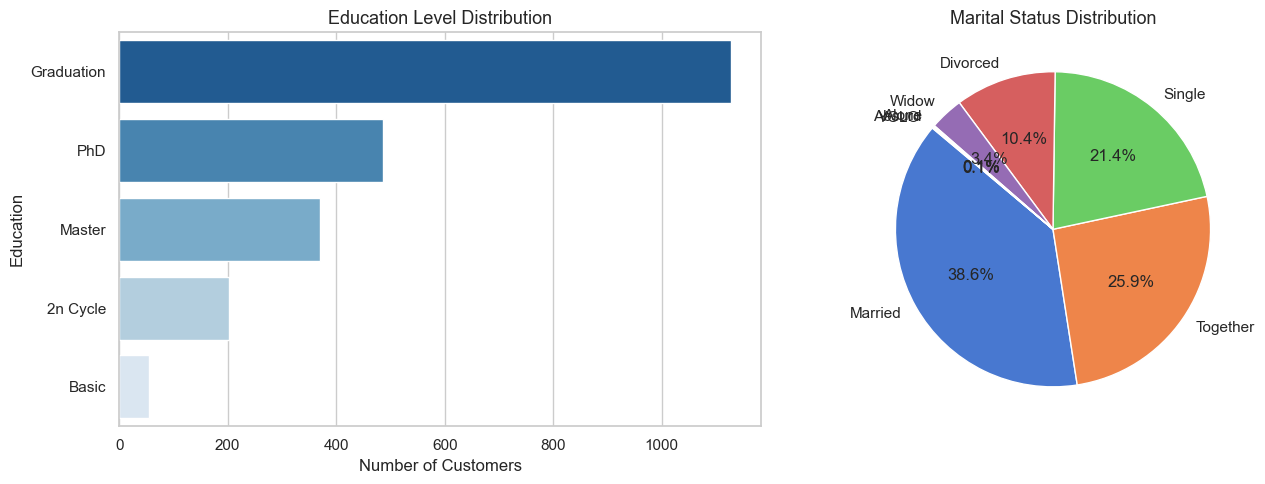

Education counts:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54

Marital status counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_counts = campaign['Education'].value_counts()
sns.barplot(x=edu_counts.values, y=edu_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Education Level Distribution', fontsize=13)
axes[0].set_xlabel('Number of Customers')

mar_counts = campaign['Marital_Status'].value_counts()
axes[1].pie(mar_counts.values, labels=mar_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('muted', len(mar_counts)))
axes[1].set_title('Marital Status Distribution', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_demographics.png'), dpi=150)
plt.show()

print('Education counts:')
print(edu_counts.to_string())
print('\nMarital status counts:')
print(mar_counts.to_string())

> **Observation.** `Marital_Status` contains junk categories like 'YOLO' and 'Absurd' alongside the standard ones. Flagged for consolidation in Phase 2.

### 6c. Income distribution

Income Summary:
count      2216.00
mean      52247.25
std       25173.08
min        1730.00
25%       35303.00
50%       51381.50
75%       68522.00
max      666666.00
Name: Income, dtype: float64

Income > $200K: 1 customers (flagged for Phase 2)


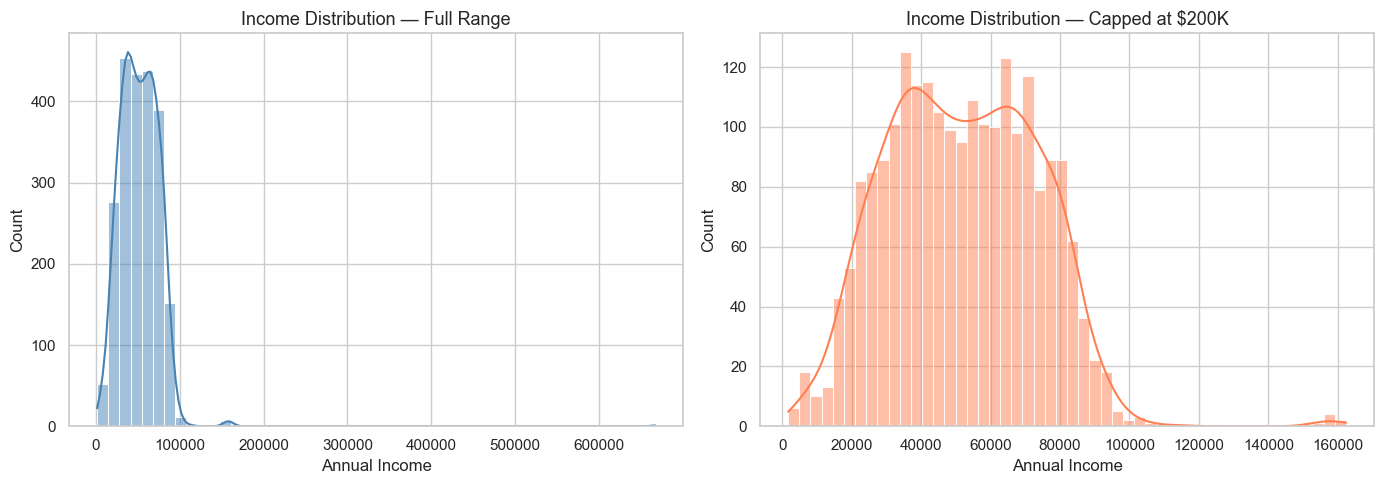

In [12]:
print('Income Summary:')
print(campaign['Income'].describe().round(2))
print(f'\nIncome > $200K: {(campaign["Income"] > 200000).sum()} customers (flagged for Phase 2)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution including any extreme outliers
sns.histplot(campaign['Income'].dropna(), bins=50,
             ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Income Distribution — Full Range', fontsize=13)
axes[0].set_xlabel('Annual Income')

# Capped at 200K to show the main distribution clearly
sns.histplot(
    campaign[campaign['Income'] < 200000]['Income'].dropna(),
    bins=50, ax=axes[1], color='coral', kde=True
)
axes[1].set_title('Income Distribution — Capped at $200K', fontsize=13)
axes[1].set_xlabel('Annual Income')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_income.png'), dpi=150)
plt.show()

### 6d. Household composition
`Kidhome` and `Teenhome` tell us how many children and teenagers live in each
household. Family structure often correlates strongly with purchasing behaviour.

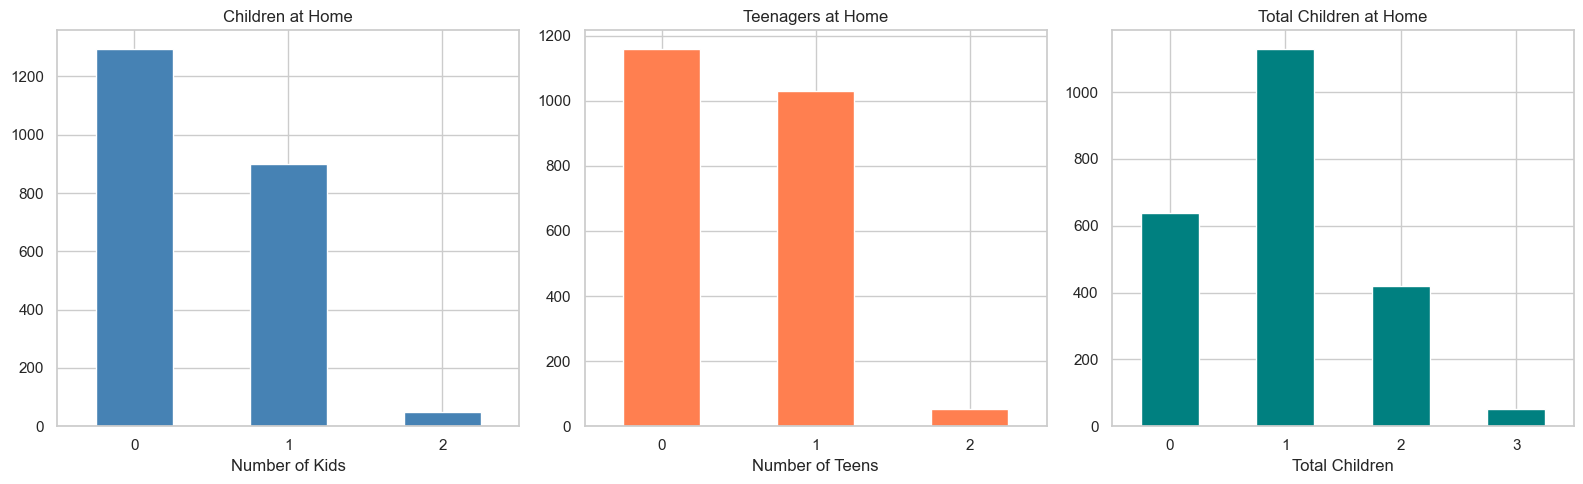

In [13]:
# Combined children count across both age groups
campaign['Total_Children'] = campaign['Kidhome'] + campaign['Teenhome']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

campaign['Kidhome'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Children at Home', fontsize=12)
axes[0].set_xlabel('Number of Kids')

campaign['Teenhome'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', rot=0)
axes[1].set_title('Teenagers at Home', fontsize=12)
axes[1].set_xlabel('Number of Teens')

campaign['Total_Children'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='teal', rot=0)
axes[2].set_title('Total Children at Home', fontsize=12)
axes[2].set_xlabel('Total Children')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_household.png'), dpi=150)
plt.show()

---
## 7. Spending analysis
The dataset contains spending across 6 product categories over the last 2 years.
Understanding where customers spend tells us which categories drive revenue
and sets up our market basket analysis in Phase 6.

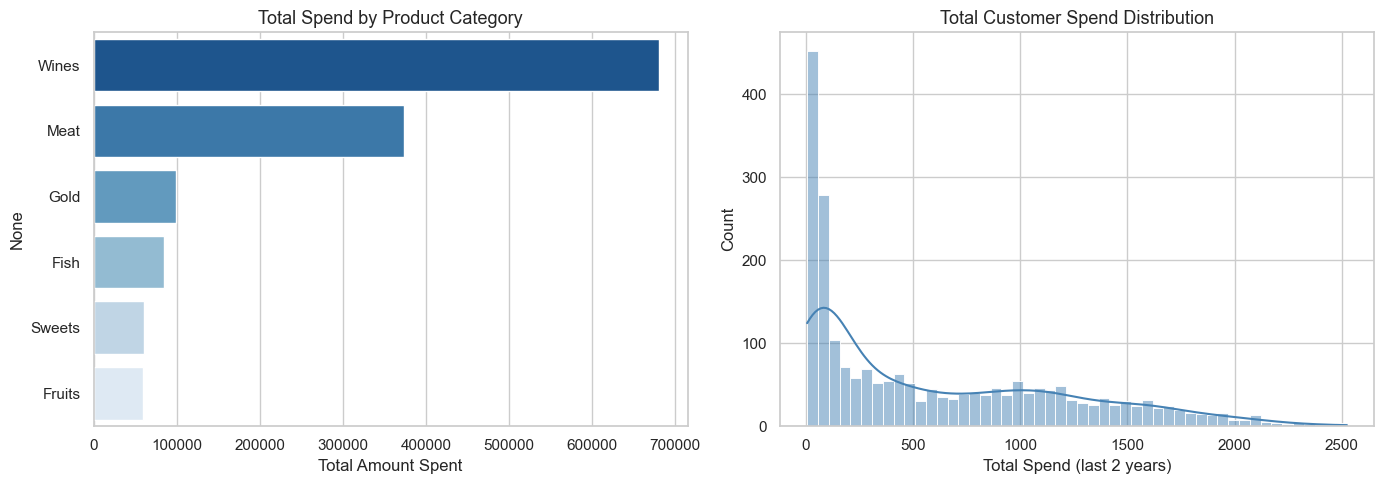

Total spend per category (correctly labelled):
  Wines        $   680,816
  Meat         $   373,968
  Gold         $    98,609
  Fish         $    84,057
  Sweets       $    60,621
  Fruits       $    58,917


In [14]:
# Define spending columns with readable labels
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spend_labels = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

# Total spending per customer across all categories
campaign['TotalSpend'] = campaign[spend_cols].sum(axis=1)

# Total spend per category across all customers
# CRITICAL: rename the index BEFORE sorting, otherwise labels get scrambled.
category_totals = campaign[spend_cols].sum()
category_totals.index = spend_labels
category_totals = category_totals.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=category_totals.values, y=category_totals.index,
            ax=axes[0], palette='Blues_r')
axes[0].set_title('Total Spend by Product Category', fontsize=13)
axes[0].set_xlabel('Total Amount Spent')

sns.histplot(campaign['TotalSpend'], bins=50,
             ax=axes[1], color='steelblue', kde=True)
axes[1].set_title('Total Customer Spend Distribution', fontsize=13)
axes[1].set_xlabel('Total Spend (last 2 years)')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_spending.png'), dpi=150)
plt.show()

print('Total spend per category (correctly labelled):')
for label, val in zip(category_totals.index, category_totals.values):
    print(f'  {label:<12} ${val:>10,.0f}')

### 7b. Spending correlation heatmap
Do customers who spend a lot on wines also spend a lot on meat?
Correlations between categories are foundational insight for basket analysis.

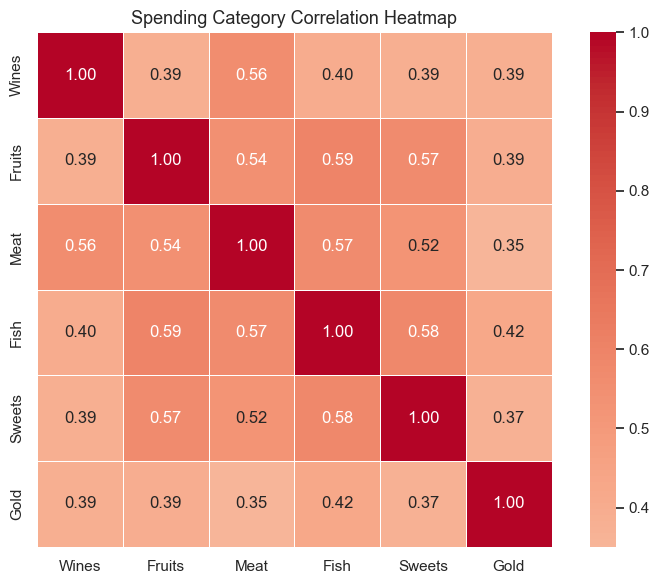

In [15]:
spend_df = campaign[spend_cols].copy()
spend_df.columns = spend_labels
corr_matrix = spend_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, square=True
)
plt.title('Spending Category Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_spending_correlation.png'), dpi=150)
plt.show()

---
## 8. Purchase channel analysis
Customers buy through four channels: web, catalogue, store, or deals.
Understanding channel preference helps us know where to invest marketing budget.

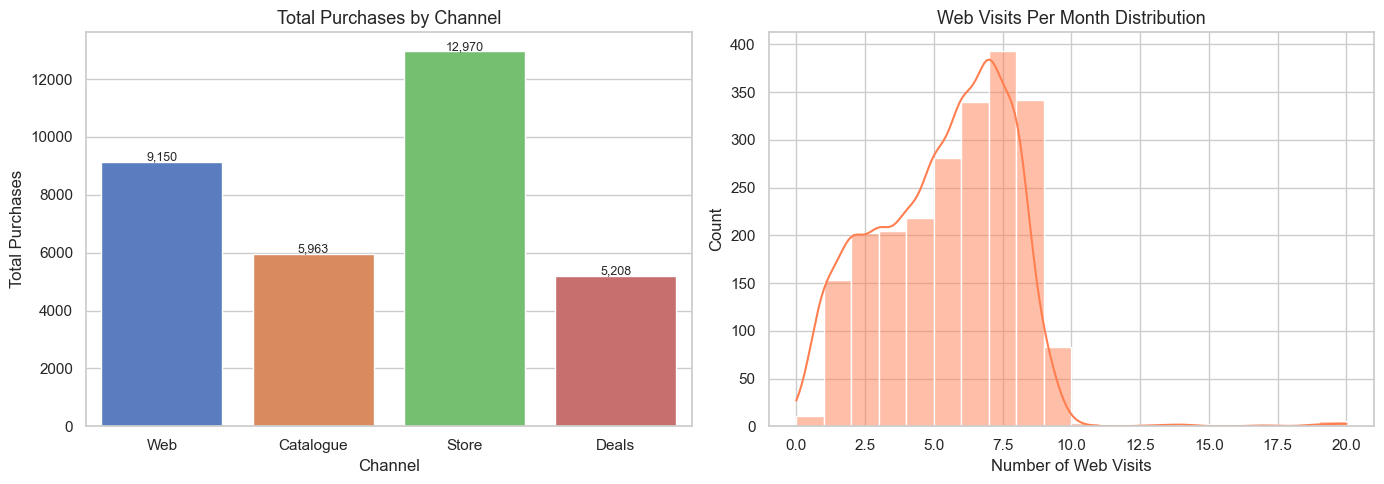

Total purchases per channel:
  Web           9,150 purchases
  Catalogue     5,963 purchases
  Store        12,970 purchases
  Deals         5,208 purchases


In [16]:
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumDealsPurchases']
channel_labels = ['Web', 'Catalogue', 'Store', 'Deals']

channel_totals = campaign[channel_cols].sum()
channel_totals.index = channel_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=channel_totals.index, y=channel_totals.values,
            ax=axes[0], palette='muted')
axes[0].set_title('Total Purchases by Channel', fontsize=13)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Total Purchases')
for i, v in enumerate(channel_totals.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# High web visits but low web purchases signals a conversion opportunity
sns.histplot(campaign['NumWebVisitsMonth'], bins=20,
             ax=axes[1], color='coral', kde=True)
axes[1].set_title('Web Visits Per Month Distribution', fontsize=13)
axes[1].set_xlabel('Number of Web Visits')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_channels.png'), dpi=150)
plt.show()

print('Total purchases per channel:')
for label, val in zip(channel_labels, channel_totals.values):
    print(f'  {label:<12} {val:>6,} purchases')

---
## 9. Campaign response analysis
This is the core of our project — who responds to campaigns and why?
1 = accepted the campaign offer, 0 = did not accept.

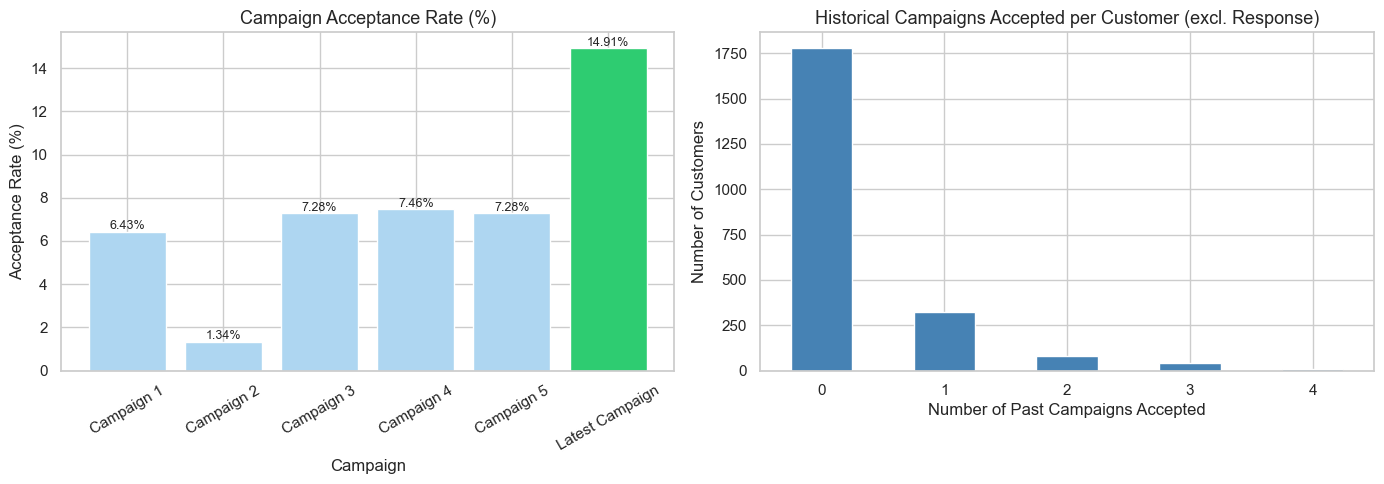

Acceptance rates:
  Campaign 1          6.43%
  Campaign 2          1.34%
  Campaign 3          7.28%
  Campaign 4          7.46%
  Campaign 5          7.28%
  Latest Campaign    14.91%


In [17]:
# Historical campaigns 1–5 plus the latest campaign (Response)
cmp_cols   = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
              'AcceptedCmp4', 'AcceptedCmp5', 'Response']
cmp_labels = ['Campaign 1', 'Campaign 2', 'Campaign 3',
              'Campaign 4', 'Campaign 5', 'Latest Campaign']

# Acceptance rate = % of customers who accepted each campaign offer
acceptance_rates = (campaign[cmp_cols].sum() / len(campaign) * 100).round(2)
acceptance_rates.index = cmp_labels

# Total HISTORICAL campaigns accepted — excludes the target (Response).
# Including Response here would create target leakage in Phase 4.
hist_cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5']
campaign['Total_Hist_Campaigns_Accepted'] = campaign[hist_cmp_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Highlight the best performing campaign in green
colors = ['#2ECC71' if v == acceptance_rates.max() else '#AED6F1'
          for v in acceptance_rates.values]
axes[0].bar(acceptance_rates.index, acceptance_rates.values, color=colors)
axes[0].set_title('Campaign Acceptance Rate (%)', fontsize=13)
axes[0].set_xlabel('Campaign')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(acceptance_rates.values):
    axes[0].text(i, v + 0.1, f'{v}%', ha='center', fontsize=9)

campaign['Total_Hist_Campaigns_Accepted'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Historical Campaigns Accepted per Customer (excl. Response)', fontsize=13)
axes[1].set_xlabel('Number of Past Campaigns Accepted')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_campaigns.png'), dpi=150)
plt.show()

print('Acceptance rates:')
for label, val in zip(acceptance_rates.index, acceptance_rates.values):
    print(f'  {label:<18} {val:>5.2f}%')

> **Leakage note.** `Response` is the target for Phase 4 propensity modelling. The "campaigns accepted per customer" feature here uses only the 5 historical campaigns (`Total_Hist_Campaigns_Accepted`) — `Response` is deliberately excluded so this feature is safe to use downstream.

### 9b. Campaign response vs customer characteristics
Do higher-income or higher-spending customers respond more to campaigns?

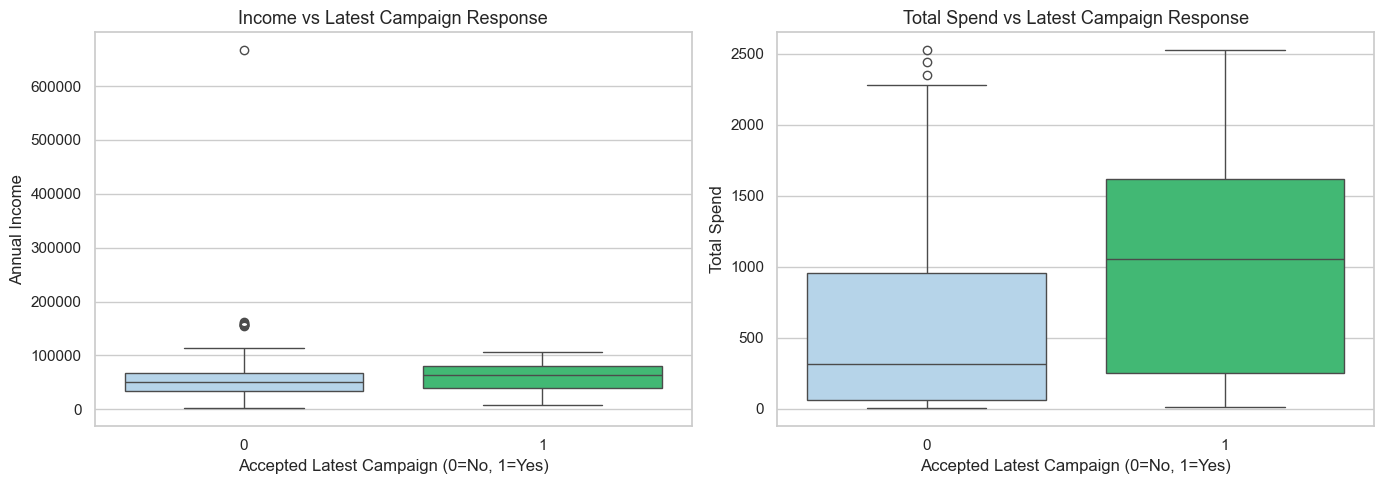

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

campaign_clean = campaign.dropna(subset=['Income'])
sns.boxplot(
    data=campaign_clean, x='Response', y='Income',
    ax=axes[0], palette=['#AED6F1', '#2ECC71']
)
axes[0].set_title('Income vs Latest Campaign Response', fontsize=13)
axes[0].set_xlabel('Accepted Latest Campaign (0=No, 1=Yes)')
axes[0].set_ylabel('Annual Income')

sns.boxplot(
    data=campaign, x='Response', y='TotalSpend',
    ax=axes[1], palette=['#AED6F1', '#2ECC71']
)
axes[1].set_title('Total Spend vs Latest Campaign Response', fontsize=13)
axes[1].set_xlabel('Accepted Latest Campaign (0=No, 1=Yes)')
axes[1].set_ylabel('Total Spend')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_response_profile.png'), dpi=150)
plt.show()

---
## 10. Recency analysis
Recency tells us how recently each customer last made a purchase.
Lower values mean more recent.

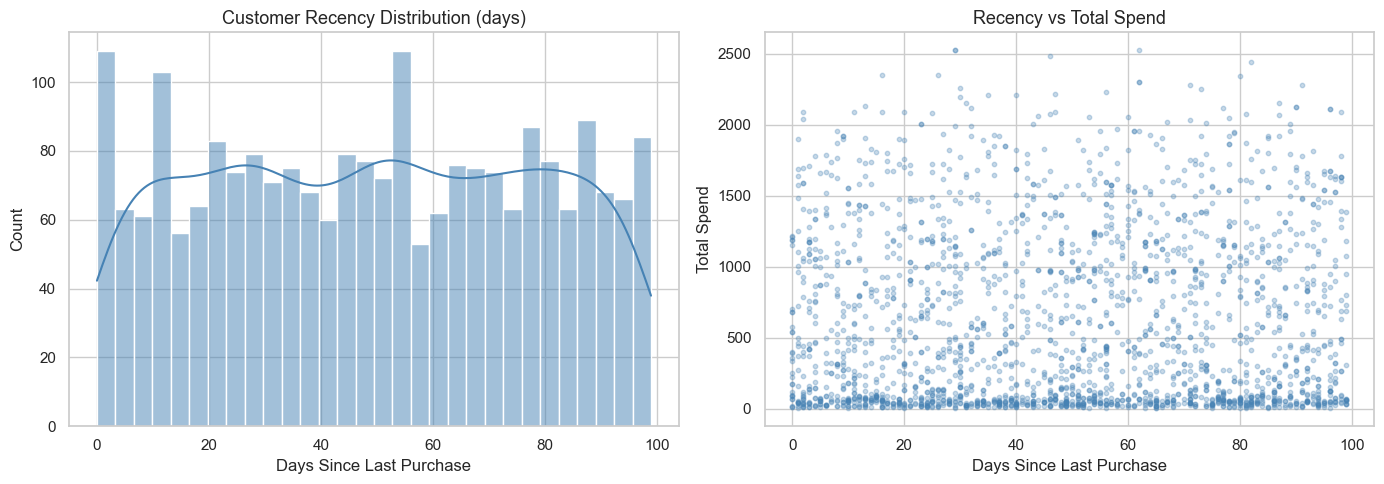

Recency Summary (days):
count    2240.0
mean       49.1
std        29.0
min         0.0
25%        24.0
50%        49.0
75%        74.0
max        99.0
Name: Recency, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(campaign['Recency'], bins=30,
             ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Customer Recency Distribution (days)', fontsize=13)
axes[0].set_xlabel('Days Since Last Purchase')

# Scatter plot — do recent buyers also spend more?
axes[1].scatter(campaign['Recency'], campaign['TotalSpend'],
                alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Recency vs Total Spend', fontsize=13)
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Total Spend')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_recency.png'), dpi=150)
plt.show()

print('Recency Summary (days):')
print(campaign['Recency'].describe().round(1))

---
## 11. Reviews dataset — Structure overview
A quick look at the Amazon reviews dataset used for sentiment analysis in Phase 5.

**Reminder:** this dataset is **not joinable** to the campaign dataset. Findings here are standalone.

In [20]:
print('Reviews Dataset — Columns:')
print(reviews.dtypes)
print(f'\nShape: {reviews.shape}')

Reviews Dataset — Columns:
id                         str
dateAdded                  str
dateUpdated                str
name                       str
asins                      str
brand                      str
categories                 str
primaryCategories          str
imageURLs                  str
keys                       str
manufacturer               str
manufacturerNumber         str
reviews.date               str
reviews.dateSeen           str
reviews.didPurchase     object
reviews.doRecommend     object
reviews.id             float64
reviews.numHelpful     float64
reviews.rating           int64
reviews.sourceURLs         str
reviews.text               str
reviews.title              str
reviews.username           str
sourceURLs                 str
dtype: object

Shape: (28332, 24)


In [21]:
# Coverage check — how many unique products / reviewers / date range
print('Coverage:')
print(f'  Unique products (by name):     {reviews["name"].nunique():,}')
if 'reviews.username' in reviews.columns:
    print(f'  Unique reviewers (by username): {reviews["reviews.username"].nunique():,}')
if 'reviews.date' in reviews.columns:
    dates = pd.to_datetime(reviews['reviews.date'], errors='coerce')
    print(f'  Date range:                     {dates.min().date()} → {dates.max().date()}')
print()
print('Sample reviews:')
print(reviews[['name', 'reviews.rating', 'reviews.title', 'reviews.text']].head(5).to_string())

Coverage:
  Unique products (by name):     65
  Unique reviewers (by username): 16,268
  Date range:                     2009-02-26 → 2019-03-25

Sample reviews:
                                                         name  reviews.rating                                                                             reviews.title                                                                                                                                 reviews.text
0  AmazonBasics AAA Performance Alkaline Batteries (36 Count)               3  ... 3 of them and one of the item is bad quality. Is missing backup spring so I have ...  I order 3 of them and one of the item is bad quality. Is missing backup spring so I have to put a pcs of aluminum to make the battery work.
1  AmazonBasics AAA Performance Alkaline Batteries (36 Count)               4                                 ... always the less expensive way to go for products like                                                     

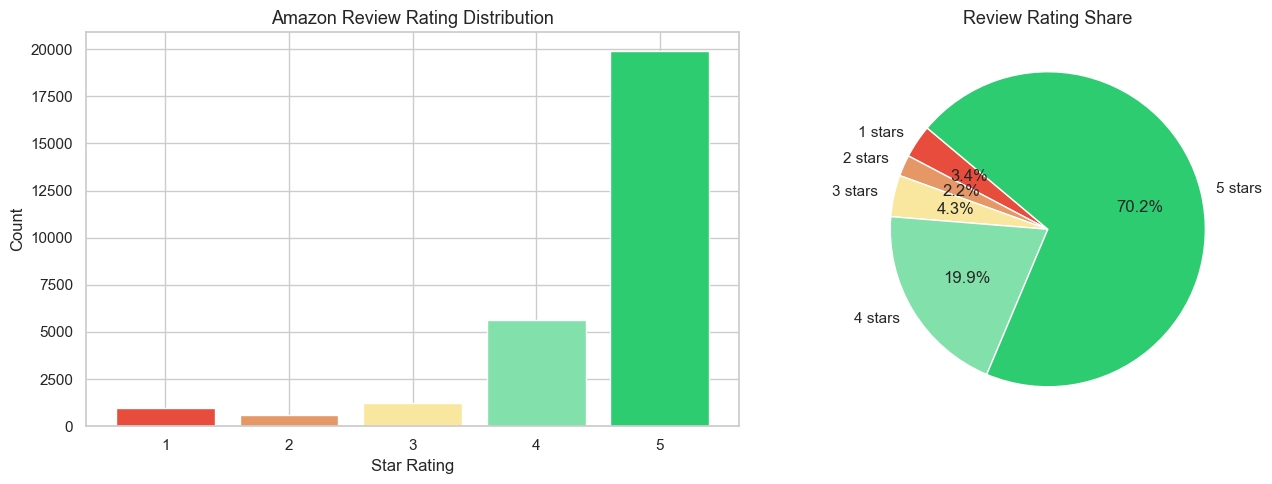

Rating Distribution:
  1 stars: 965 (3.4%)
  2 stars: 616 (2.2%)
  3 stars: 1,206 (4.3%)
  4 stars: 5,648 (19.9%)
  5 stars: 19,897 (70.2%)

Class distribution if mapped to sentiment (pos/neu/neg):
  Positive (4-5 stars): 25,545 (90.2%)
  Neutral  (3 stars):   1,206 (4.3%)
  Negative (1-2 stars): 1,581 (5.6%)
  → Strong positive skew — class balancing strategy required in Phase 5.


In [22]:
# Rating distribution
# Class imbalance here will affect how we train the sentiment model in Phase 5
rating_counts = reviews['reviews.rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E74C3C', '#E59866', '#F9E79F', '#82E0AA', '#2ECC71']
axes[0].bar(rating_counts.index.astype(str),
            rating_counts.values, color=colors)
axes[0].set_title('Amazon Review Rating Distribution', fontsize=13)
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')

axes[1].pie(rating_counts.values,
            labels=[f'{int(i)} stars' for i in rating_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Review Rating Share', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_review_ratings.png'), dpi=150)
plt.show()

print('Rating Distribution:')
for rating, count in rating_counts.items():
    pct = count / len(reviews) * 100
    print(f'  {rating} stars: {count:,} ({pct:.1f}%)')

# Class imbalance summary for Phase 5 planning
pos = (reviews['reviews.rating'] >= 4).sum()
neu = (reviews['reviews.rating'] == 3).sum()
neg = (reviews['reviews.rating'] <= 2).sum()
print(f'\nClass distribution if mapped to sentiment (pos/neu/neg):')
print(f'  Positive (4-5 stars): {pos:,} ({pos/len(reviews)*100:.1f}%)')
print(f'  Neutral  (3 stars):   {neu:,} ({neu/len(reviews)*100:.1f}%)')
print(f'  Negative (1-2 stars): {neg:,} ({neg/len(reviews)*100:.1f}%)')
print('  → Strong positive skew — class balancing strategy required in Phase 5.')

Review Text Length Summary (characters):
count    28332.0
mean       138.0
std        200.0
min          1.0
25%         54.0
50%         87.0
75%        162.0
max       8351.0
Name: review_length, dtype: float64

Very short reviews (<20 chars): 2,538


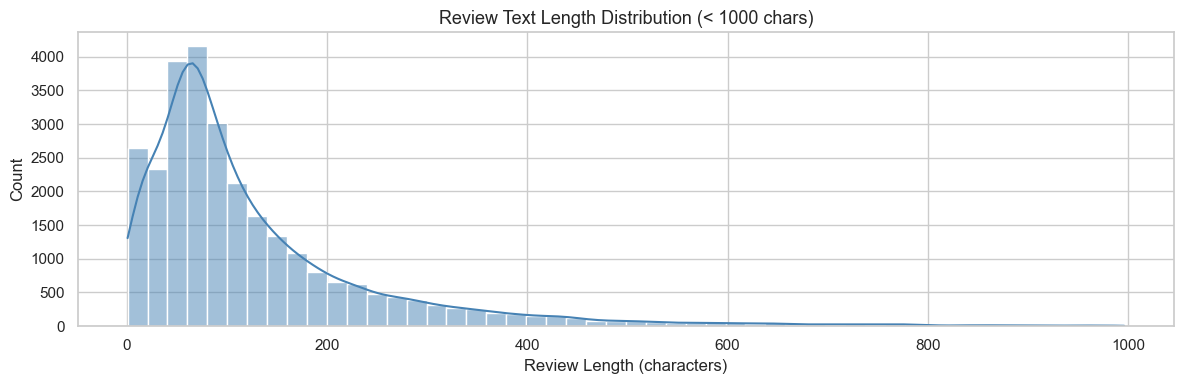

In [23]:
# Review text length — very short reviews may not contain enough signal
# for sentiment analysis, so we need to know the distribution
reviews['review_length'] = reviews['reviews.text'].astype(str).apply(len)

print('Review Text Length Summary (characters):')
print(reviews['review_length'].describe().round(0))
print(f'\nVery short reviews (<20 chars): {(reviews["review_length"] < 20).sum():,}')

plt.figure(figsize=(12, 4))
sns.histplot(
    reviews[reviews['review_length'] < 1000]['review_length'],
    bins=50, color='steelblue', kde=True
)
plt.title('Review Text Length Distribution (< 1000 chars)', fontsize=13)
plt.xlabel('Review Length (characters)')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'eda_review_length.png'), dpi=150)
plt.show()

---
## 12. EDA summary

In [24]:
print('=' * 60)
print('EDA SUMMARY — MARKETING CAMPAIGN ANALYSIS')
print('=' * 60)
print()
print('--- Campaign Dataset ---')
print(f'Total customers:          {len(campaign):,}')
print(f'Age reference year:       {REFERENCE_YEAR} (derived from max Dt_Customer)')
print(f'Average age:              {campaign["Age"].mean():.0f} years')
print(f'Average income:           ${campaign["Income"].mean():,.0f}')
print(f'Average total spend:      ${campaign["TotalSpend"].mean():,.0f}')
print(f'Top spending category:    {category_totals.index[0]} (${category_totals.iloc[0]:,.0f})')
print(f'Top purchase channel:     {channel_totals.idxmax()} ({channel_totals.max():,} purchases)')
print(f'Best campaign:            {acceptance_rates.idxmax()} ({acceptance_rates.max()}%)')
print(f'Latest campaign response: {campaign["Response"].mean()*100:.1f}% acceptance rate')
print(f'Customers with children:  {(campaign["Total_Children"] > 0).sum():,} ({(campaign["Total_Children"] > 0).mean()*100:.1f}%)')
print()
print('--- Reviews Dataset ---')
print(f'Total reviews:            {len(reviews):,}')
print(f'Unique products:          {reviews["name"].nunique():,}')
print(f'Average rating:           {reviews["reviews.rating"].mean():.2f} / 5')
print(f'5-star reviews:           {(reviews["reviews.rating"] == 5).sum():,} ({(reviews["reviews.rating"] == 5).mean()*100:.1f}%)')
print(f'1-star reviews:           {(reviews["reviews.rating"] == 1).sum():,} ({(reviews["reviews.rating"] == 1).mean()*100:.1f}%)')
print(f'Avg review length:        {reviews["review_length"].mean():.0f} characters')
print('=' * 60)

EDA SUMMARY — MARKETING CAMPAIGN ANALYSIS

--- Campaign Dataset ---
Total customers:          2,240
Age reference year:       2014 (derived from max Dt_Customer)
Average age:              45 years
Average income:           $52,247
Average total spend:      $606
Top spending category:    Wines ($680,816)
Top purchase channel:     Store (12,970 purchases)
Best campaign:            Latest Campaign (14.91%)
Latest campaign response: 14.9% acceptance rate
Customers with children:  1,602 (71.5%)

--- Reviews Dataset ---
Total reviews:            28,332
Unique products:          65
Average rating:           4.51 / 5
5-star reviews:           19,897 (70.2%)
1-star reviews:           965 (3.4%)
Avg review length:        138 characters


### Key findings & decisions carried into later phases

**Cross-dataset framing**
- The campaign and reviews datasets share **no join key**. Phase 5 sentiment is standalone — it cannot be tied to specific customers, CLV tiers, or campaign responders. Any conclusion linking the two would be a logical error.

**Data quality actions for Phase 2 — Cleaning**
- Drop constant columns `Z_CostContact` and `Z_Revenue` (std = 0, no information).
- Remove the 3 customers with `Year_Birth ≤ 1900` (implied age 120+).
- Remove the customer with `Income = $666,666` (data entry artefact).
- Drop the 24 missing-income rows (no strong systematic difference — see Section 5a).
- Consolidate `Marital_Status` junk categories (`YOLO`, `Absurd`, `Alone`) into `Single`.
- De-duplicate the reviews dataset on `(name, reviews.text)` before sentiment training.

**Leakage flag for Phase 4**
- `Response` is the target. Any "campaigns accepted" feature must use only `AcceptedCmp1–5` (already built as `Total_Hist_Campaigns_Accepted`). Do not include `Response` in feature engineering for itself.

**Phase 5 class imbalance**
- Amazon ratings are heavily skewed positive (~70% are 5-star). A sentiment model trained on raw class proportions will be near-useless on the negative class. Plan for class weighting, resampling, or threshold tuning in Phase 5, and evaluate with **confusion matrix → classification report → AUC-ROC** in that order (never accuracy alone).

**Reviewer satisfaction caveat**
- Amazon ratings reflect customers who *chose* to leave a review. They are a measure of reviewer sentiment, not all-customer sentiment.

✅ EDA complete. Proceed to Phase 2 — Data Cleaning & DB Loading.